In [128]:
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.integrate import odeint
torch.manual_seed(0)
np.random.seed(0)

## Generate synthetic data that follows known disease rates

In [130]:
# We choose the true rates
TRUE = {"beta": 0.50, "gamma":0.20, "omega": 1.0/14.0}

N_POP = 1_000_000.0  # total population

T_max = 160.0  # 160 days

I0 = 1/N_POP # one person infected at t=0

Y0 = [1-I0, I0, 0, 0]  # initial conditon [s, i, r, d ] at t=0

def sird_rhs(y, t, beta, gamma, omega):
    s, i, r, d = y
    return [-beta * s * i,
           beta * s * i - gamma * i - omega * i,
           gamma * i,
           omega * i]

def simulate(times, p):
    return odeint(sird_rhs, Y0, times, args = (p["beta"], p["gamma"], p["omega"]))

t_train = np.arange(0.0, T_max + 1e-9, 3.0)    # sparse: observation every 3 days
t_dense = np.arange(0.0, T_max + 1e-9, 1.0)     # dense grid for ploting
y_train = simulate(t_train, TRUE)          # Observed data
y_dense_true = simulate(t_dense, TRUE)         # ground truth for final ploting

We visualize the true curves

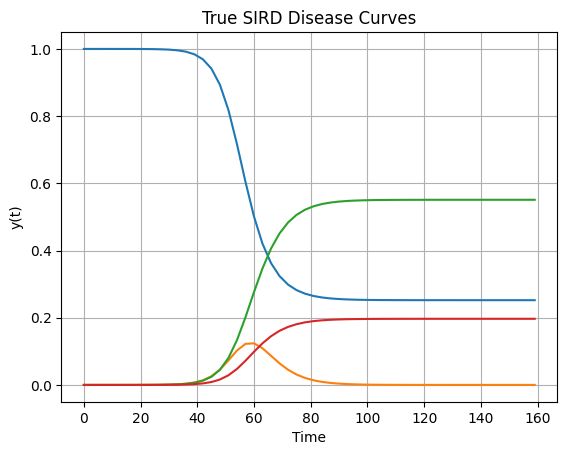

In [132]:
plt.plot(t_train, y_train)
plt.xlabel("Time")
plt.ylabel("y(t)")
plt.title("True SIRD Disease Curves")
plt.grid()
plt.show()

## Build a custom neural network for SIRD model

In [134]:
# This custom neural network model is designed to accept one input (time) and produce 4 outputs (s, i, r, d)

class MLP(nn.Module):
    def __init__(self, hidden =32, depth= 3):
        super().__init__()
        layers = [nn.Linear(1,hidden), nn.Tanh()]
        for i in range(depth-1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 4)]
        self.net = nn.Sequential(*layers)

    def forward(self, tau):
        return self.net(tau)

model = MLP()

## Train unknown rates

We start with a wrong parameter values and train them accordingly 

In [137]:
Guess = {"beta": 0.80, "gamma":0.10, "omega":0.15}

# Train the parameters
log_beta = nn.Parameter(torch.log(torch.tensor(Guess["beta"])))
log_gamma = nn.Parameter(torch.log(torch.tensor(Guess["gamma"])))
log_omega = nn.Parameter(torch.log(torch.tensor(Guess["omega"])))

def rates():
    return torch.exp(log_beta), torch.exp(log_gamma), torch.exp(log_omega)

## Build a customized loss function

In [139]:
# We start with the data loss
tau_train = torch.tensor(t_train/T_max, dtype = torch.float32).reshape(-1,1)
y_obs = torch.tensor(y_train, dtype=torch.float32)
mse = nn.MSELoss()
loss_data = mse(model(tau_train), y_obs)

# Initial condition loss
                         